# Title: Spread Locator: A Statistical Distribution Analysis Model #


## 🔹 Part B - Data Analysis & Testing Tasks: ## 

# Question 1
# Fit the data to Bernoulli and Binomial Distributions (transaction occurrence & weekly count)

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import bernoulli, binom
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel("spread_locator_dataset.xlsx")

# Convert date column
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Bernoulli Distribution
df["Occurrence"] = np.where(df["transaction_amount"] > 0, 1, 0)

p = df["Occurrence"].mean()

print("Probability of Transaction =", p)

print("P(Success) =", bernoulli.pmf(1, p))
print("P(Failure) =", bernoulli.pmf(0, p))

Probability of Transaction = 1.0
P(Success) = 1.0
P(Failure) = 0.0


# Binomial Distribution

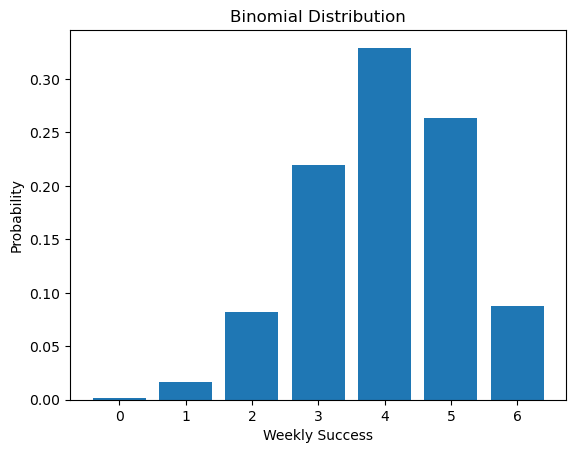

In [4]:
weekly = df.resample("W", on="transaction_date").size()

n = len(weekly)

success = np.sum(weekly > weekly.mean())

p = success / n

x = np.arange(0, n + 1)

prob = binom.pmf(x, n, p)

plt.bar(x, prob)

plt.title("Binomial Distribution")

plt.xlabel("Weekly Success")

plt.ylabel("Probability")

plt.show()

# Question 2
# Fit the data to Poisson Distribution (number of transactions per day)

Lambda = 7.096774193548387


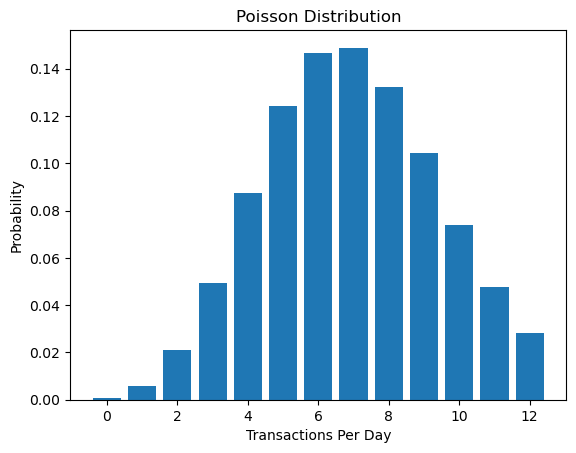

In [5]:
from scipy.stats import poisson

daily = df.resample("D", on="transaction_date").size()

lam = daily.mean()

print("Lambda =", lam)

x = np.arange(0, max(daily)+1)

plt.bar(x, poisson.pmf(x, lam))

plt.title("Poisson Distribution")

plt.xlabel("Transactions Per Day")

plt.ylabel("Probability")

plt.show()

# Question 3
# Model transaction amounts using Log-Normal and Power Law Distributions

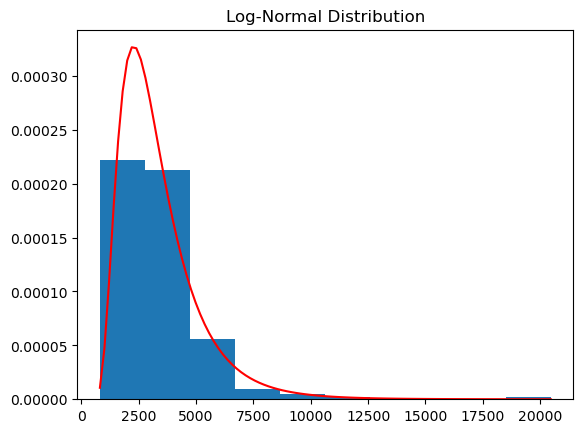

In [7]:
from scipy.stats import lognorm

amount = df["transaction_amount"]

shape, loc, scale = lognorm.fit(amount)

x = np.linspace(amount.min(), amount.max(), 100)

pdf = lognorm.pdf(x, shape, loc, scale)

plt.hist(amount, density=True)

plt.plot(x, pdf, color="red")

plt.title("Log-Normal Distribution")

plt.show()

# Power Law

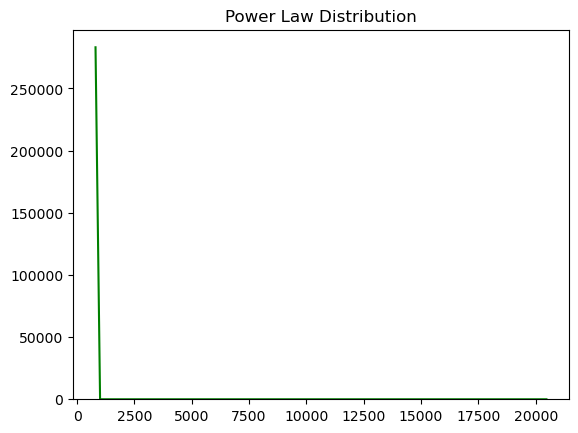

In [8]:
from scipy.stats import powerlaw

a, loc, scale = powerlaw.fit(amount)

pdf = powerlaw.pdf(x, a, loc, scale)

plt.hist(amount, density=True)

plt.plot(x, pdf, color="green")

plt.title("Power Law Distribution")

plt.show()

# Question 4
# Generate and Interpret a Q-Q Plot

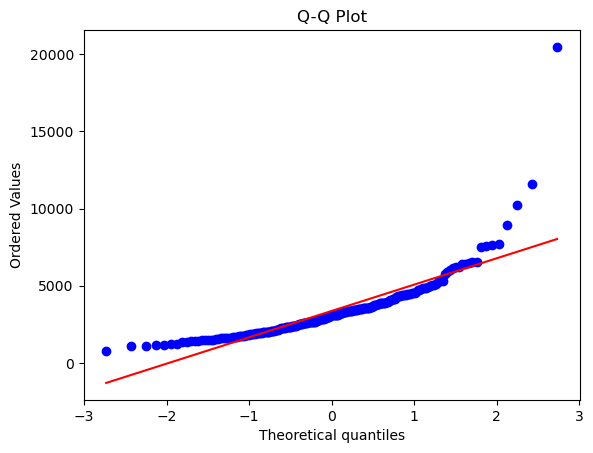

In [9]:
from scipy import stats

stats.probplot(amount, dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.show()

# Question 5
# Apply Box-Cox Transform

Lambda = -0.18123612911845818


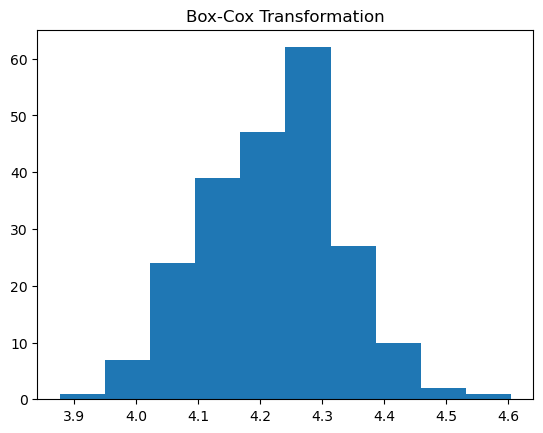

In [10]:
from scipy.stats import boxcox

positive = amount + 1

transformed, lam = boxcox(positive)

print("Lambda =", lam)

plt.hist(transformed)

plt.title("Box-Cox Transformation")

plt.show()

# Question 6
# Calculate Z-Score and Probability > ₹5000

In [11]:
from scipy.stats import zscore, norm

df["Z-Score"] = zscore(amount)

print(df[["transaction_amount","Z-Score"]].head())

   transaction_amount   Z-Score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


# Probability

In [12]:
mean = amount.mean()

std = amount.std()

z = (5000-mean)/std

prob = 1 - norm.cdf(z)

print("Probability Above ₹5000 =", prob)

Probability Above ₹5000 = 0.20517209567554384


# Question 7
# Plot PDF and CDF

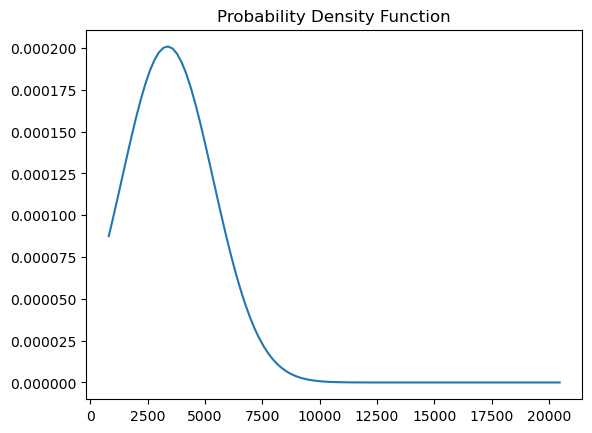

In [13]:
from scipy.stats import norm

mean = amount.mean()

std = amount.std()

x = np.linspace(amount.min(), amount.max(),100)

pdf = norm.pdf(x, mean, std)

plt.plot(x, pdf)

plt.title("Probability Density Function")

plt.show()

# CDF

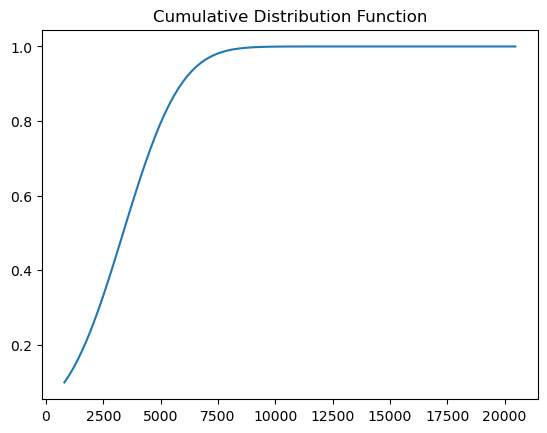

In [14]:
cdf = norm.cdf(x, mean, std)

plt.plot(x, cdf)

plt.title("Cumulative Distribution Function")

plt.show()

# Question 8
# Conclude Which Distribution Best Fits the Dataset

In [15]:
print("Conclusion")

print("Bernoulli Distribution : Best for transaction occurrence.")

print("Binomial Distribution : Best for weekly successful transactions.")

print("Poisson Distribution : Best for daily transaction counts.")

print("Log-Normal Distribution : Best for transaction amounts.")

print("Power Law Distribution : Useful for heavy-tailed transaction data.")

print("Q-Q Plot : Checks normality.")

print("Box-Cox : Reduces skewness.")

print("Z-Score : Detects outliers.")

print("PDF & CDF : Explain transaction probabilities.")

Conclusion
Bernoulli Distribution : Best for transaction occurrence.
Binomial Distribution : Best for weekly successful transactions.
Poisson Distribution : Best for daily transaction counts.
Log-Normal Distribution : Best for transaction amounts.
Power Law Distribution : Useful for heavy-tailed transaction data.
Q-Q Plot : Checks normality.
Box-Cox : Reduces skewness.
Z-Score : Detects outliers.
PDF & CDF : Explain transaction probabilities.
